In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("./../data/balanced_data.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33924 entries, 0 to 33923
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  33924 non-null  object 
 1   cc_num                 33924 non-null  int64  
 2   merchant               33924 non-null  object 
 3   category               33924 non-null  object 
 4   amt                    33924 non-null  float64
 5   first                  33924 non-null  object 
 6   last                   33924 non-null  object 
 7   gender                 33924 non-null  object 
 8   street                 33924 non-null  object 
 9   city                   33924 non-null  object 
 10  state                  33924 non-null  object 
 11  zip                    33924 non-null  int64  
 12  lat                    33924 non-null  float64
 13  long                   33924 non-null  float64
 14  city_pop               33924 non-null  int64  
 15  jo

In [2]:
data['trans_date_trans_time'] = pd.to_datetime(data['trans_date_trans_time'])
data['dob'] = pd.to_datetime(data['dob'])

data['age'] = (data['trans_date_trans_time'] - data['dob']).dt.days // 365

data['hour'] = data['trans_date_trans_time'].dt.hour       
data['weekday'] = data['trans_date_trans_time'].dt.weekday 
data['day'] = data['trans_date_trans_time'].dt.day         
data['month'] = data['trans_date_trans_time'].dt.month     
data['year'] = data['trans_date_trans_time'].dt.year 

<Axes: >

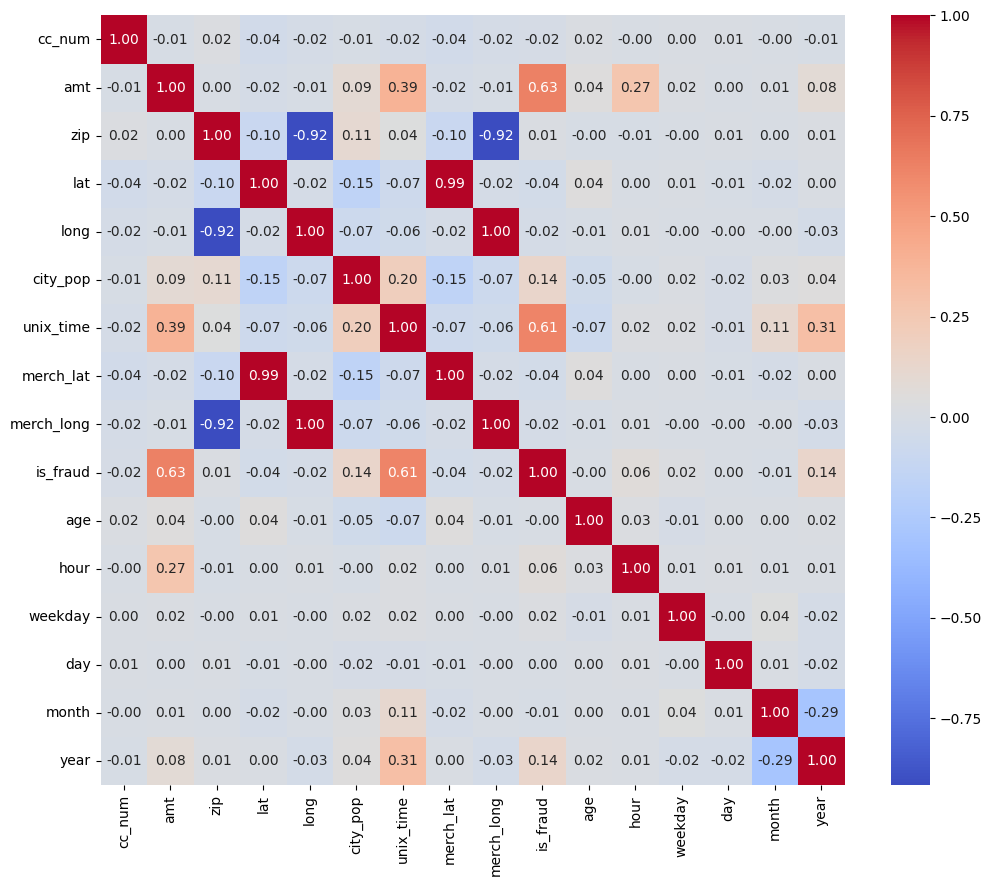

In [3]:
numeric_data = data.select_dtypes(include="number")
plt.figure(figsize=(12,10))
sns.heatmap(numeric_data.corr(), annot=True, fmt=".2f", cmap="coolwarm")

In [4]:
numeric_data = numeric_data.drop(columns=["cc_num", "zip", "unix_time", "merch_lat", "merch_long", "year"])
numeric_data.columns

Index(['amt', 'lat', 'long', 'city_pop', 'is_fraud', 'age', 'hour', 'weekday',
       'day', 'month'],
      dtype='object')

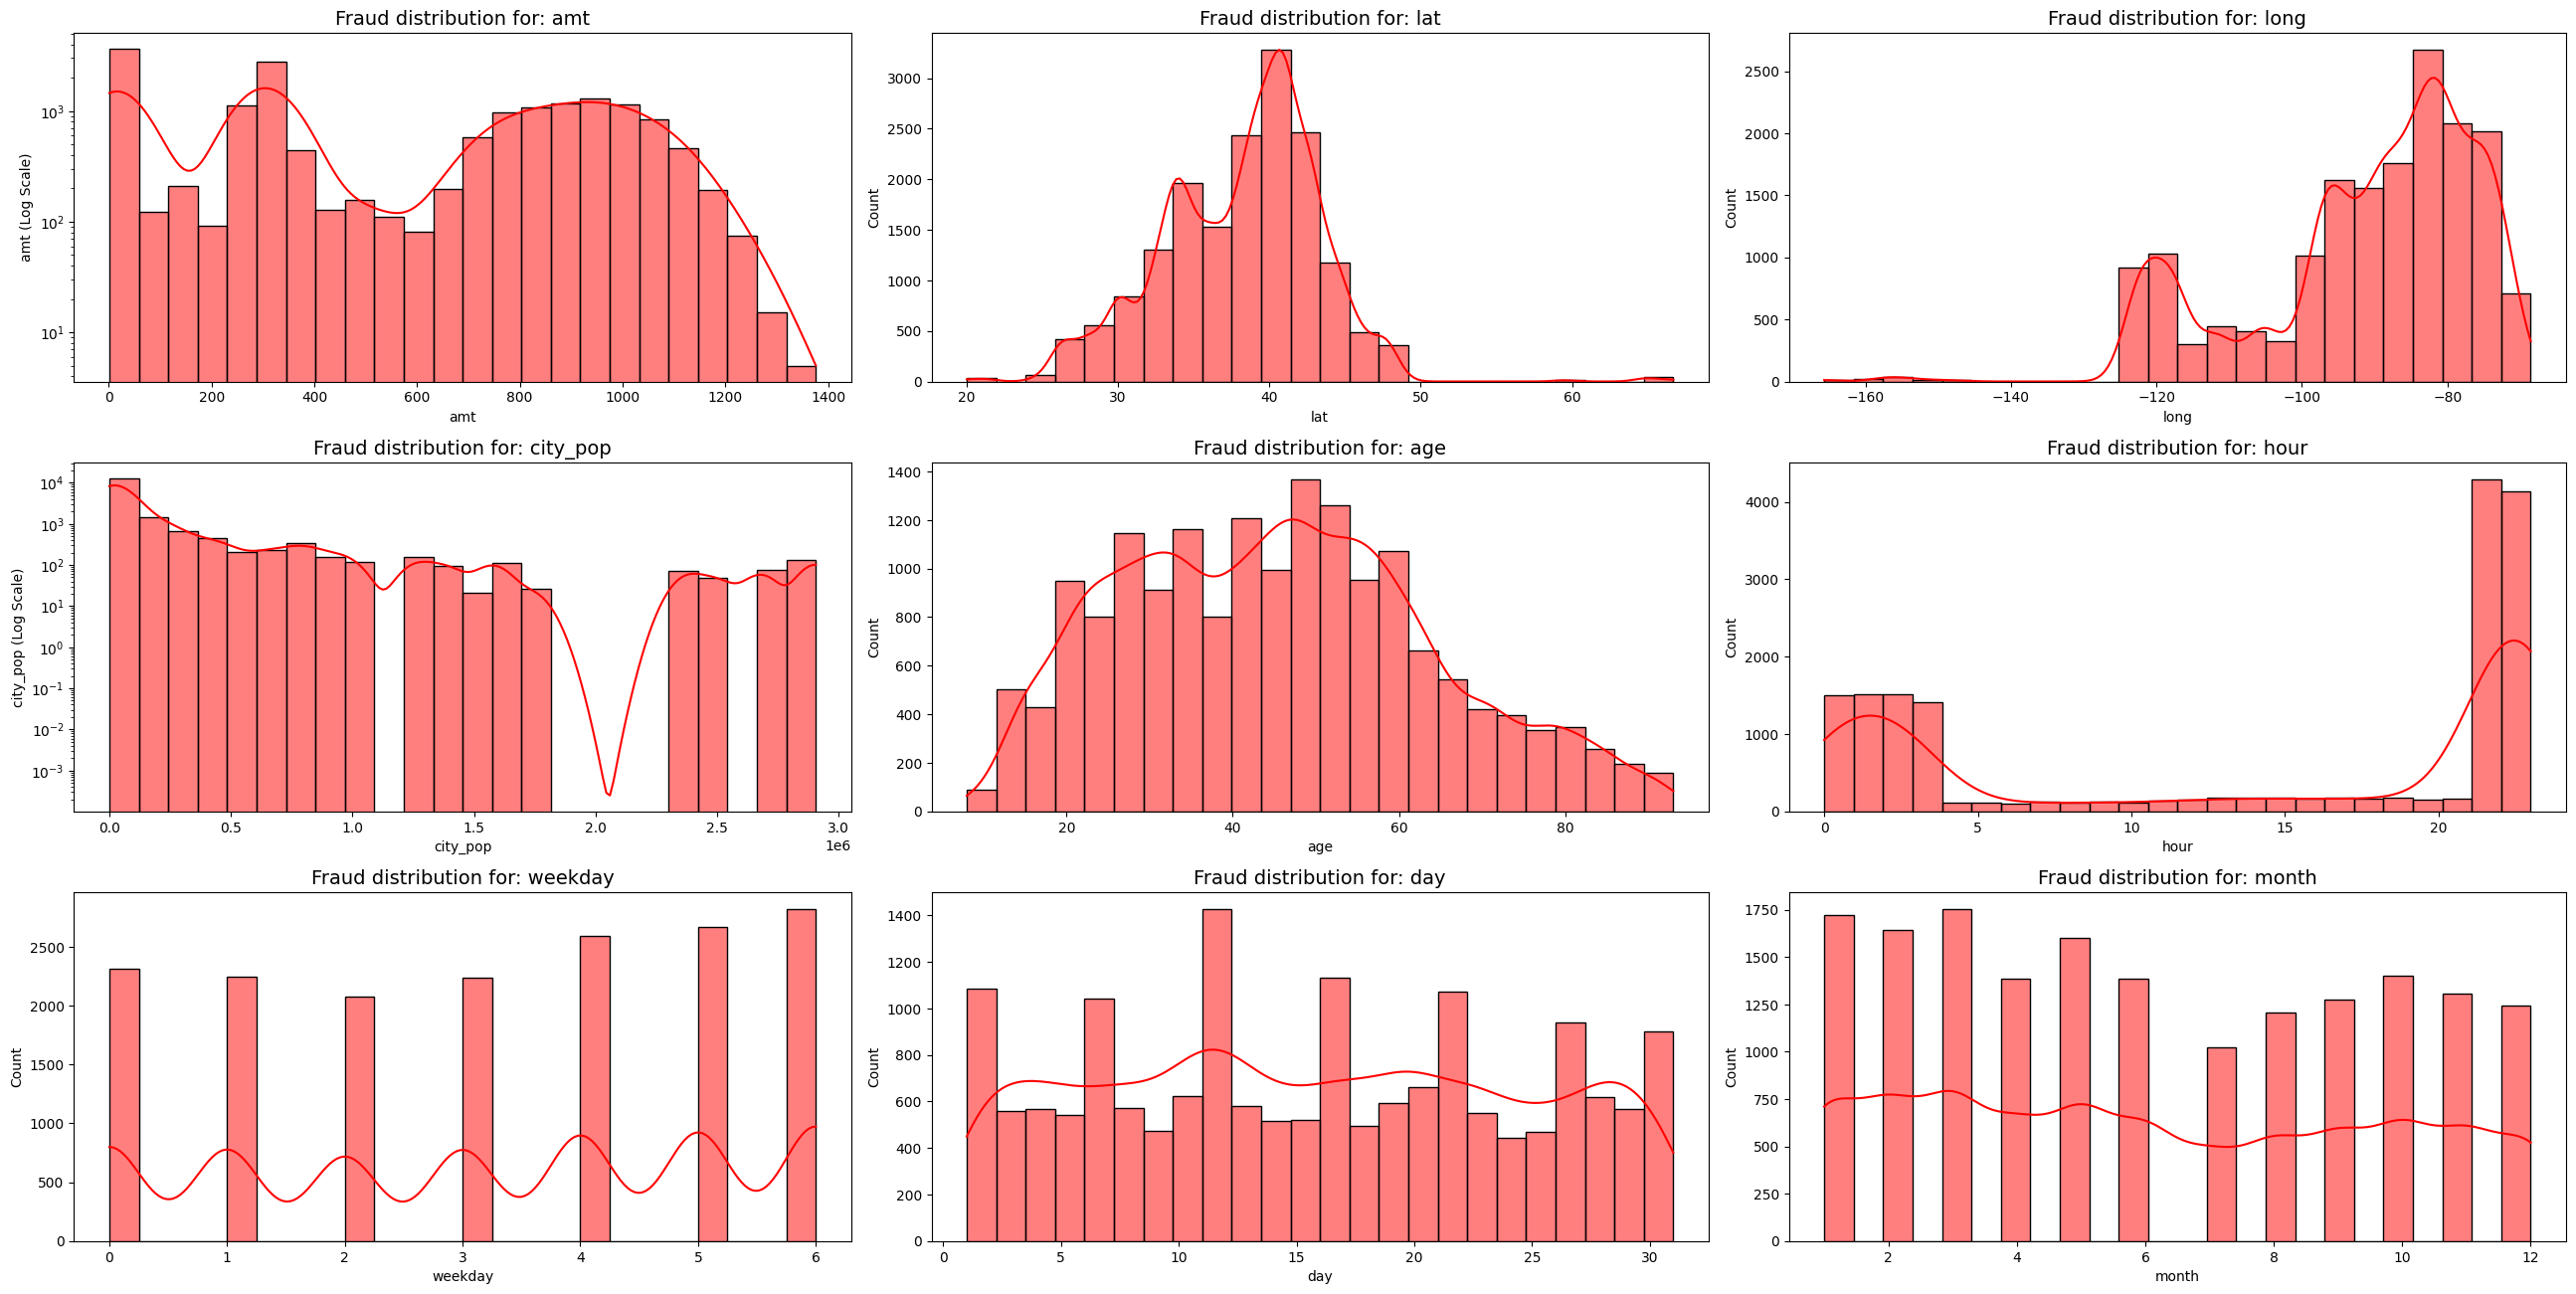

In [5]:
numerical_cols = numeric_data.columns.drop("is_fraud")

plt.figure(figsize=(26, 17))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    fraud_data = data[data['is_fraud'] == 1]

    sns.histplot(x=col, data=fraud_data, bins=24, color='red', kde=True)
    
    plt.title(f'Fraud distribution for: {col}', fontsize=14)

    if col in ['amt', 'city_pop']:
        plt.yscale('log')
        plt.ylabel(f'{col} (Log Scale)')

plt.tight_layout()
plt.show()

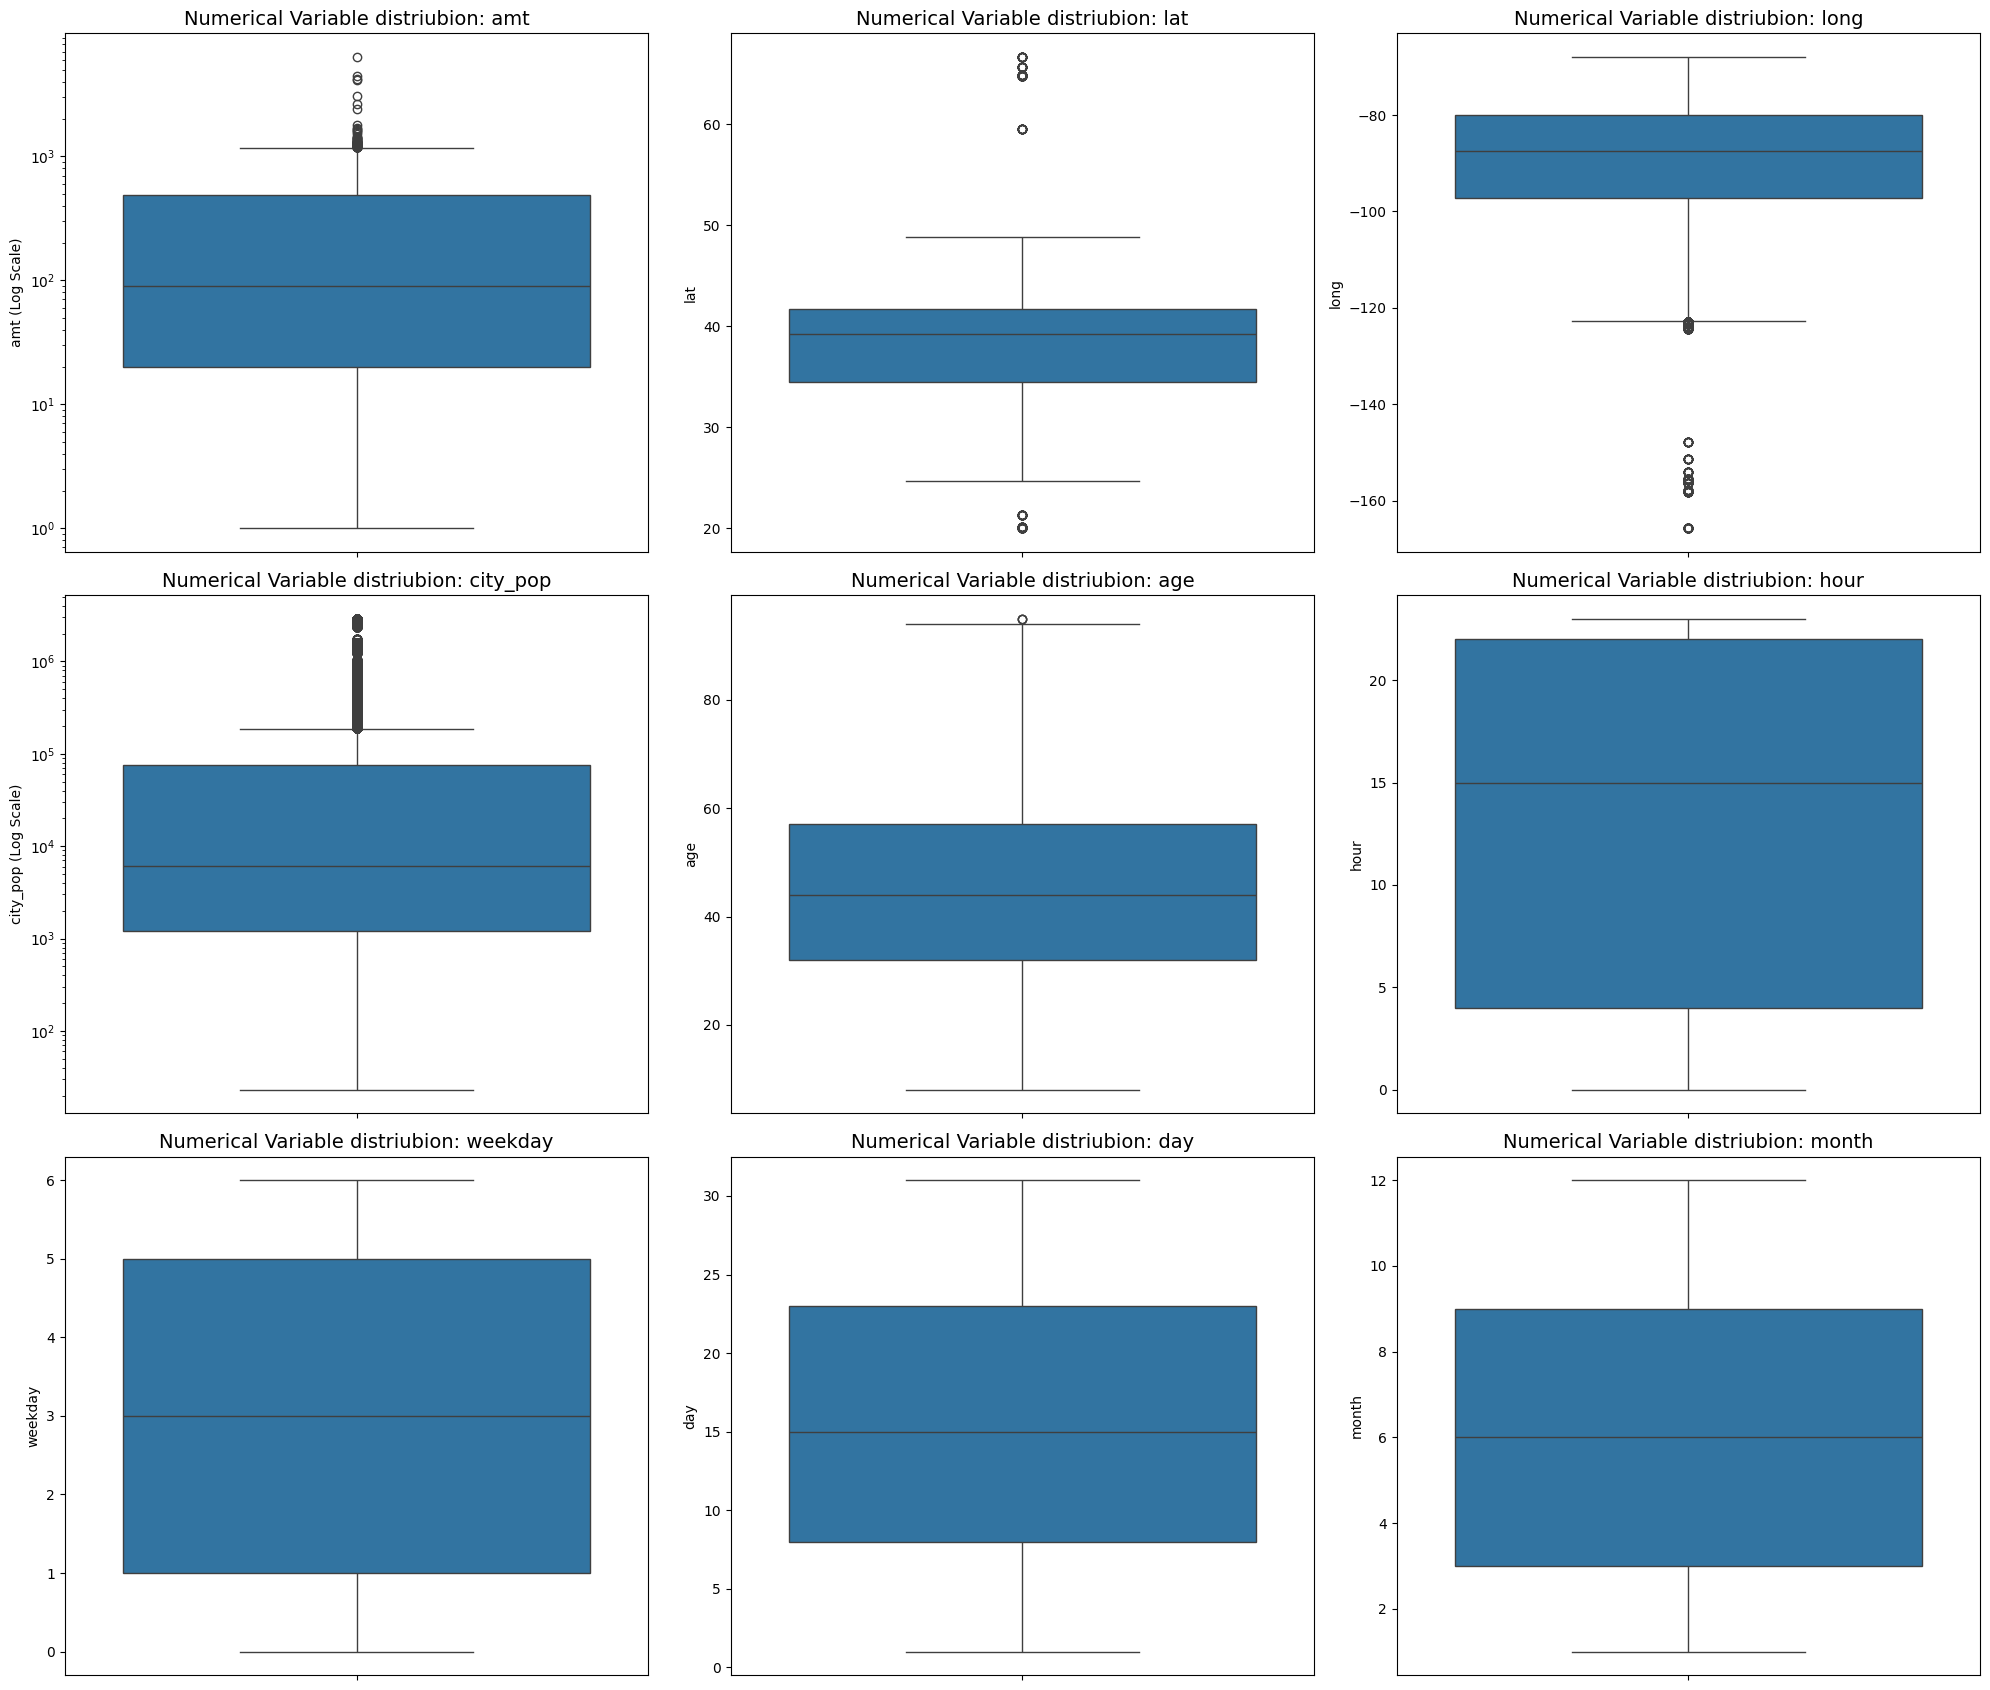

In [6]:
numerical_cols = numeric_data.columns.drop("is_fraud")

plt.figure(figsize=(20, 17))

# Loop through the columns and create a plot for each
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    
    # Use a Box Plot to compare distributions
    # This shows the Median (middle line) and Outliers (dots)
    sns.boxplot( y=col, data=data)
    
    plt.title(f'Numerical Variable distriubion: {col}', fontsize=14)
    
    # Special handling for 'amt' and 'city_pop' because values get HUGE
    # We use log scale to make the chart readable
    if col in ['amt', 'city_pop']:
        plt.yscale('log')
        plt.ylabel(f'{col} (Log Scale)')

plt.tight_layout()
plt.show()

In [7]:
numeric_data['is_night'] = (numeric_data['hour'] >= 22) | (numeric_data['hour'] <= 4)
numeric_data['is_night'] = numeric_data['is_night'].astype(int)

In [8]:
numeric_data['is_weekend'] = (numeric_data['weekday'] >= 4) & (numeric_data['weekday'] <= 6)
numeric_data['is_weekend'] = numeric_data['is_weekend'].astype(int)


--- Top Features Correlated with Fraud ---
is_fraud      1.000000
amt           0.627083
is_night      0.602351
city_pop      0.136836
hour          0.060605
weekday       0.022349
is_weekend    0.007085
day           0.003425
age          -0.002703
month        -0.008935
long         -0.024293
lat          -0.038967
Name: is_fraud, dtype: float64


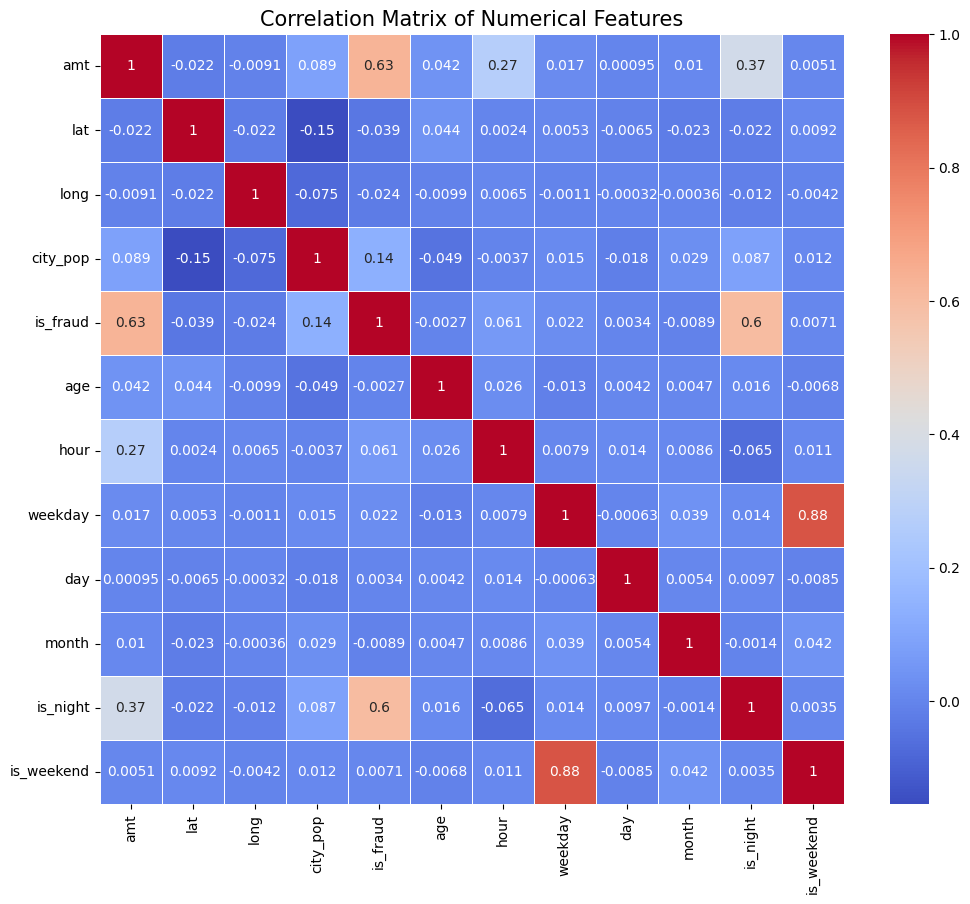

In [9]:
import numpy as np

corr_matrix = numeric_data.corr()

fraud_correlation = corr_matrix['is_fraud'].sort_values(ascending=False)
print("\n--- Top Features Correlated with Fraud ---")
print(fraud_correlation)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=15)
plt.show()

In [10]:
categorial_data = data.select_dtypes(include="object")
categorial_data = categorial_data.drop(columns='trans_num')
categorial_data.columns

Index(['merchant', 'category', 'first', 'last', 'gender', 'street', 'city',
       'state', 'job'],
      dtype='object')

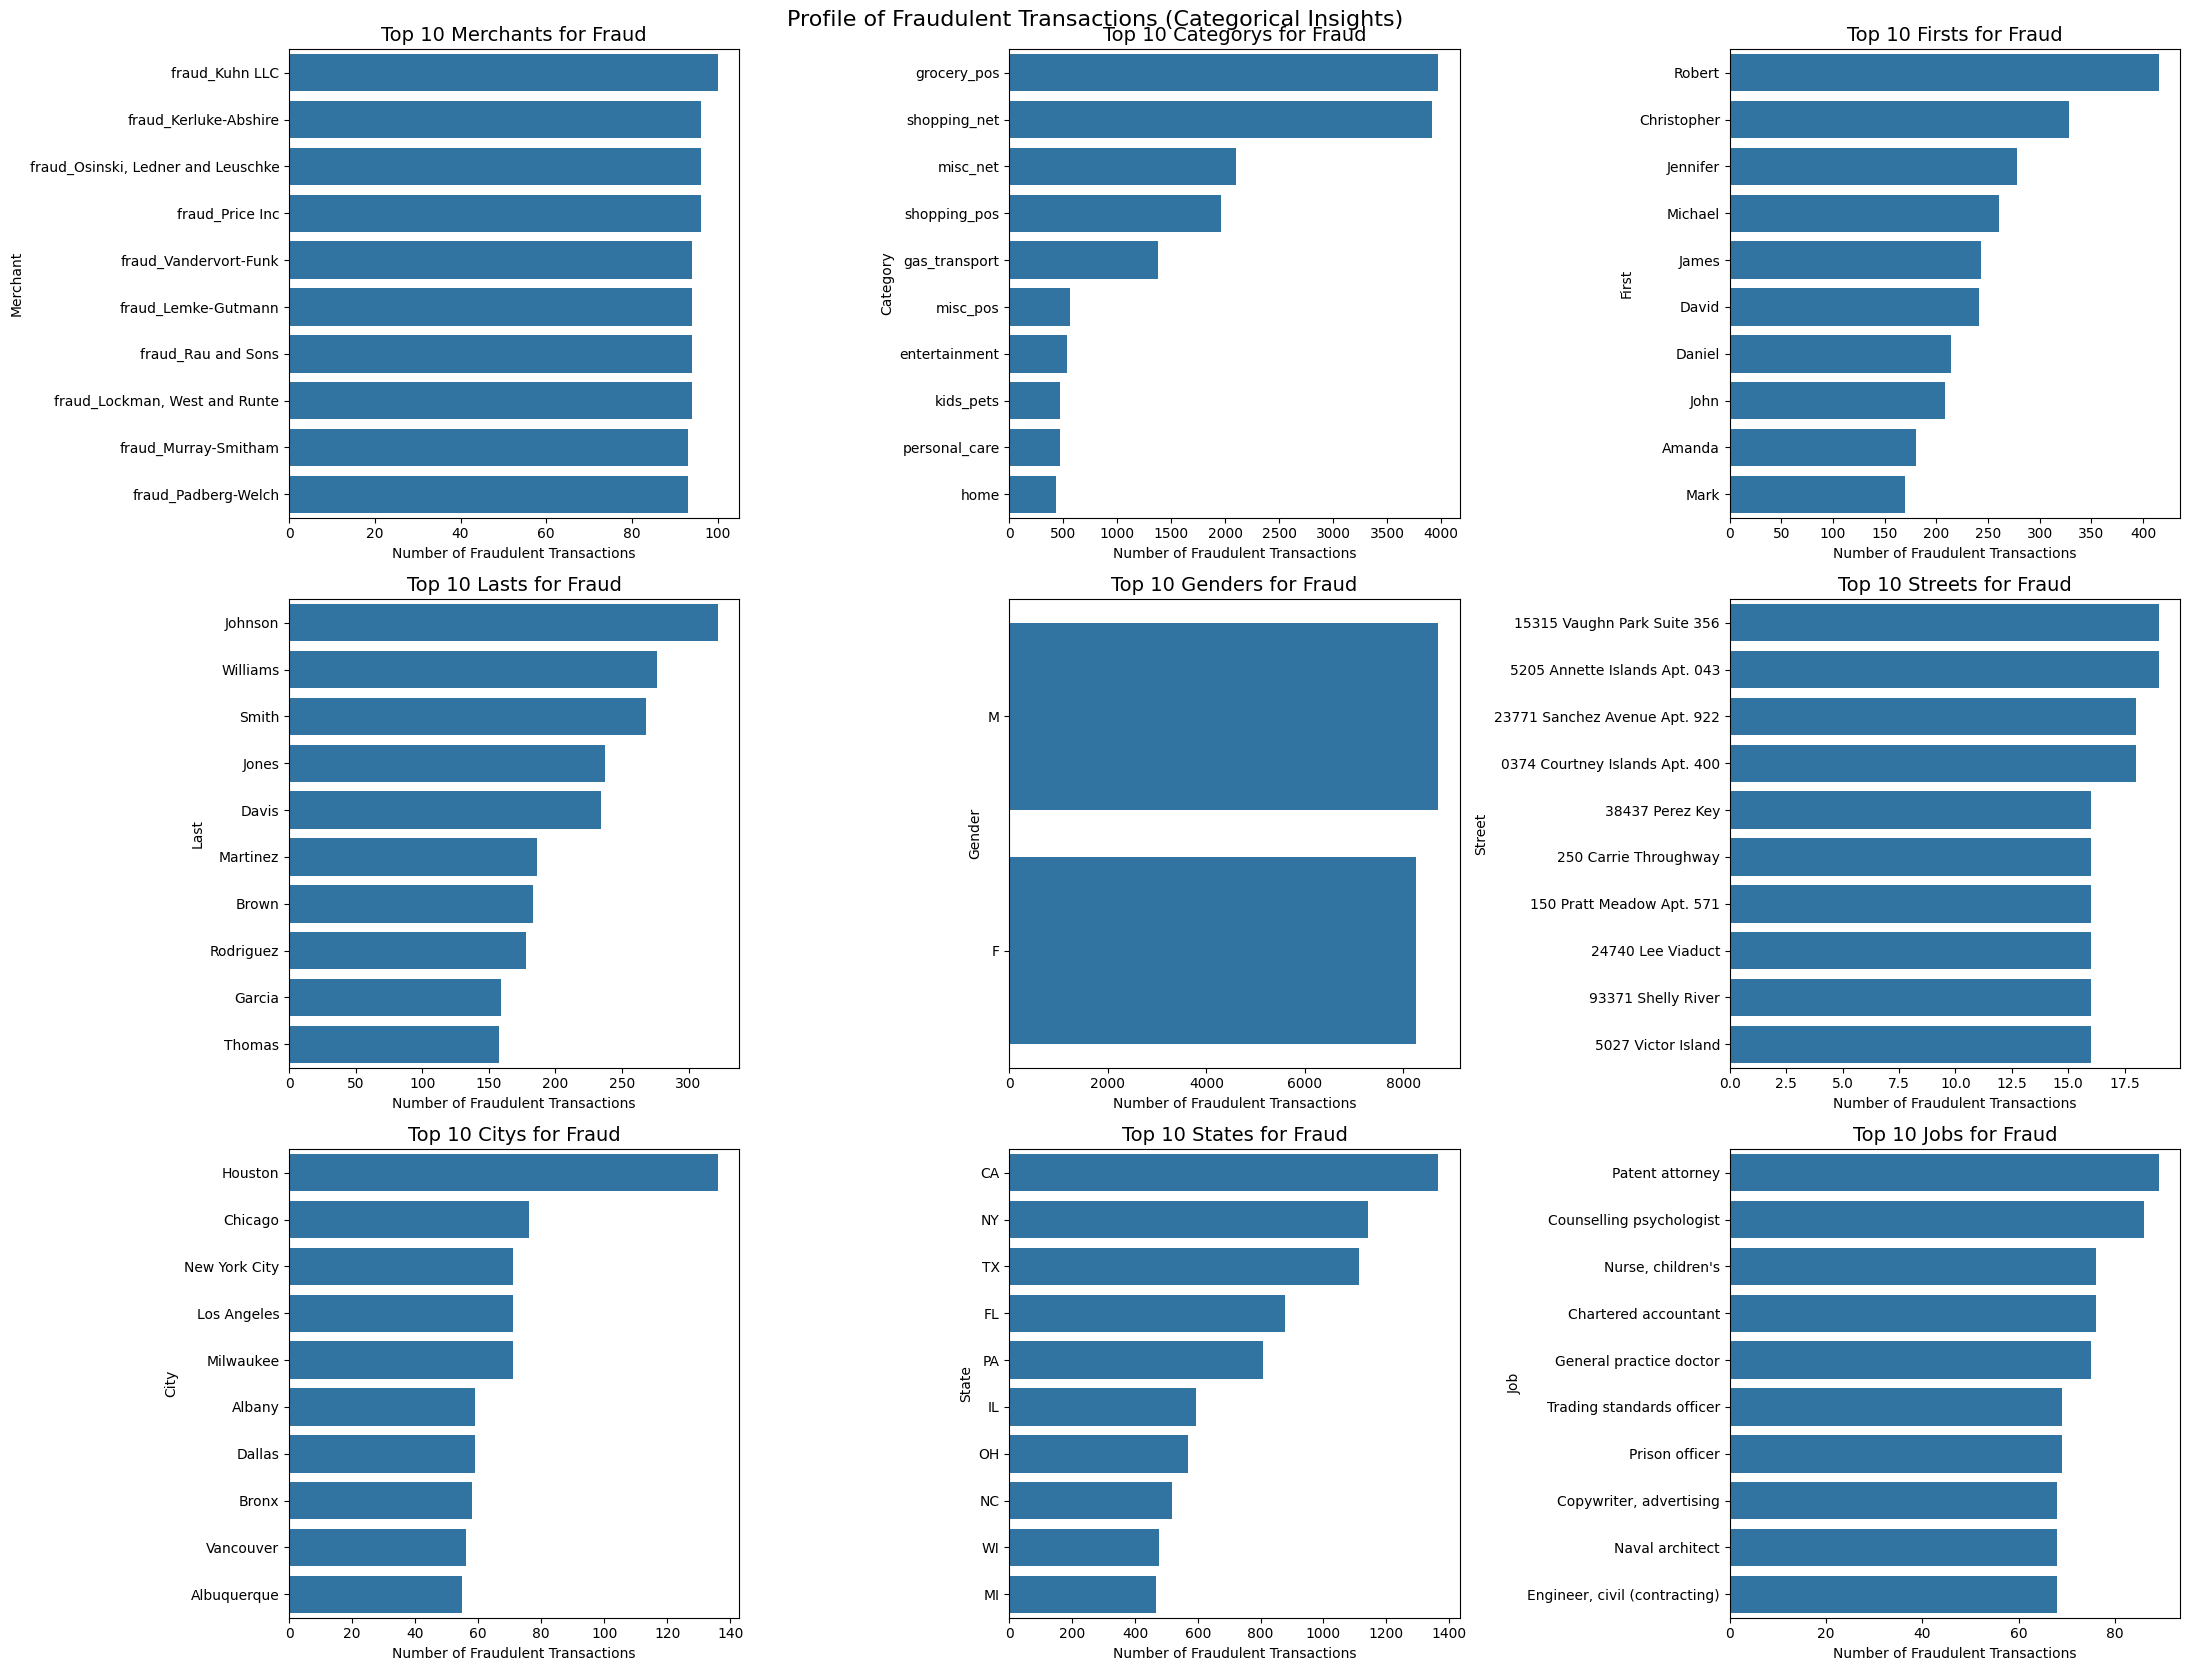

In [11]:

categorical_cols = categorial_data.columns

plt.figure(figsize=(22, 17))
plt.suptitle('Profile of Fraudulent Transactions (Categorical Insights)', fontsize=16)

# 4. Loop through columns and create plots
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    fraud_data = data[data['is_fraud'] == 1]
    top_fraud_categories = fraud_data[col].value_counts().iloc[:10].index

    sns.countplot(y=col, data=fraud_data,order=top_fraud_categories)
    
    plt.title(f'Top 10 {col.title()}s for Fraud', fontsize=14)
    plt.xlabel('Number of Fraudulent Transactions')
    plt.ylabel(col.title())

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

print("--- STATUS: Running Chi-Squared Statistical Test... ---")


print("\n{:<20} {:<15} {:<10} {:<10}".format("Feature", "Chi2 Stat", "P-Value", "Decision"))
print("-" * 60)

for col in categorial_data.columns:

    contingency_table = pd.crosstab(data[col], data['is_fraud'])
    
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    if p_value < 0.05:
        decision = "KEEP (Significant)"
    else:
        decision = "DROP (Not Significant)"


    print("{:<20} {:<15.2f} {:<10.5f} {:<10}".format(col, chi2, p_value, decision))

--- STATUS: Running Chi-Squared Statistical Test... ---

Feature              Chi2 Stat       P-Value    Decision  
------------------------------------------------------------
merchant             6674.06         0.00000    KEEP (Significant)
category             6219.62         0.00000    KEEP (Significant)
first                4753.73         0.00000    KEEP (Significant)
last                 6599.63         0.00000    KEEP (Significant)
gender               112.20          0.00000    KEEP (Significant)
street               17926.52        0.00000    KEEP (Significant)
city                 14850.25        0.00000    KEEP (Significant)
state                1020.51         0.00000    KEEP (Significant)
job                  6779.06         0.00000    KEEP (Significant)


In [13]:
data['is_night'] = (data['hour'] >= 22) | (numeric_data['hour'] <= 4)
data['is_night'] = data['is_night'].astype(int)

In [14]:
columns_to_drop = [
    'is_fraud', 'cc_num', 'first', 'last', 'street', 'trans_num', 
    'dob', 'trans_date_trans_time', 'lat', 'long', 
    'merch_lat', 'merch_long', 'year', 'zip', 'unix_time', 'hour', 'month', 'day'
]

X = data.drop(columns=columns_to_drop, errors='ignore')
y = data['is_fraud']
X.columns

Index(['merchant', 'category', 'amt', 'gender', 'city', 'state', 'city_pop',
       'job', 'age', 'weekday', 'is_night'],
      dtype='object')

In [ ]:
safe_cats = ['category', 'gender'] 


high_cardinality_cols = ['merchant', 'city', 'state', 'job']

for col in high_cardinality_cols:
    if col in X.columns:
        freq_encoding = X[col].value_counts(normalize=True)
        X[col + '_freq'] = X[col].map(freq_encoding)

        X = X.drop(col, axis=1)


X = pd.get_dummies(X, columns=[c for c in safe_cats if c in X.columns], drop_first=True)

In [16]:
from sklearn.model_selection import train_test_split



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

numeric_cols = X_train.select_dtypes(include=['number']).columns
numeric_cols = [col for col in numeric_cols if X_train[col].max() > 1] 

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

[[2908  512]
 [ 485 2880]]
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      3420
           1       0.85      0.86      0.85      3365

    accuracy                           0.85      6785
   macro avg       0.85      0.85      0.85      6785
weighted avg       0.85      0.85      0.85      6785



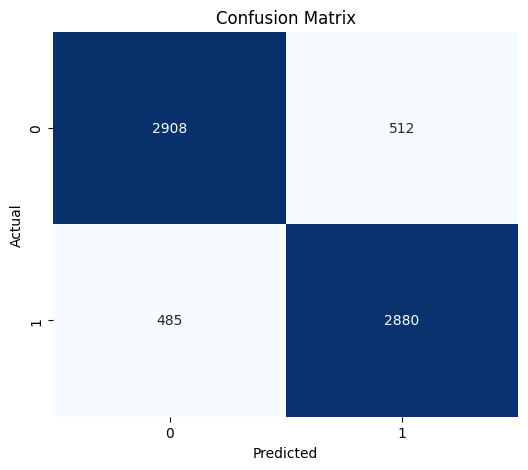

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_reg = LogisticRegression()


log_reg.fit(X_train, y_train)


y_pred_log = log_reg.predict(X_test)


print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()


[[2894  526]
 [ 449 2916]]
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      3420
           1       0.85      0.87      0.86      3365

    accuracy                           0.86      6785
   macro avg       0.86      0.86      0.86      6785
weighted avg       0.86      0.86      0.86      6785



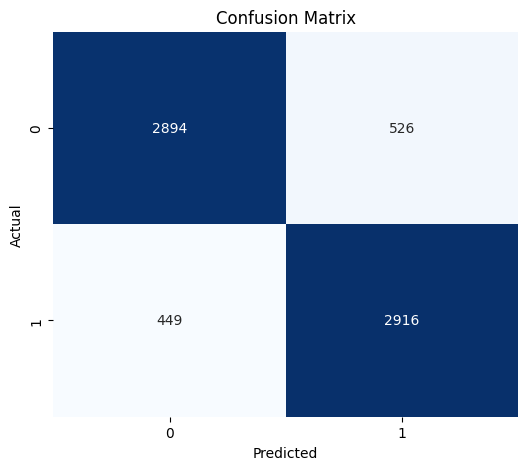

In [27]:
from sklearn.svm import LinearSVC


svm_model = LinearSVC(dual=False)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()


In [20]:
from xgboost import XGBClassifier

# Calcul du ratio pour le déséquilibre
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]

xgb_model = XGBClassifier(n_estimators=100, 
                          max_depth=6, 
                          learning_rate=0.1,
                          n_jobs=-1)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

[[2894  526]
 [ 449 2916]]
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      3420
           1       0.85      0.87      0.86      3365

    accuracy                           0.86      6785
   macro avg       0.86      0.86      0.86      6785
weighted avg       0.86      0.86      0.86      6785



In [ ]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(
    n_estimators=100,       
    max_depth=10,           
    n_jobs=-1,              
)

rf_model.fit(X_train, y_train)
y_pred_xgb = rf_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

[[2894  526]
 [ 449 2916]]
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      3420
           1       0.85      0.87      0.86      3365

    accuracy                           0.86      6785
   macro avg       0.86      0.86      0.86      6785
weighted avg       0.86      0.86      0.86      6785



In [ ]:
from sklearn.ensemble import VotingClassifier



voting_clf = VotingClassifier(
    estimators=[
        ('lr', log_reg),    
        ('xgb', xgb_model), 
        ('rf', rf_model)    
    ],
    voting='soft', 
    weights=[1, 5, 3]
)

voting_clf.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('xgb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.","[1, 5, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [ ]:
import pandas as pd
import numpy as np
import joblib

def predict_on_new_file(file_path):
    print(f"Loading data from {file_path}...")
    
   
    model = voting_clf
    scaler = joblib.load('scaler.pkl')
    
    
    model_cols = list(X.columns) 

    
    df = pd.read_csv(file_path)
    output = df.copy() 
    
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['dob'] = pd.to_datetime(df['dob'])
    
    df['hours'] = df['trans_date_trans_time'].dt.hour
    df['weekdays'] = df['trans_date_trans_time'].dt.weekday
    df['days'] = df['trans_date_trans_time'].dt.day
    df['month'] = df['trans_date_trans_time'].dt.month
    df['year'] = df['trans_date_trans_time'].dt.year
    df['unix_time'] = df.get('unix_time', 0) # Use 0 if missing
    
    df['hour'] = df['hours']
    df['is_night'] = ((df['hours'] >= 22) | (df['hours'] <= 5)).astype(int)
    df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365
    
    

    safe_cats = ['category', 'gender'] 

    high_cardinality_cols = ['merchant', 'city', 'job','state']

    for col in high_cardinality_cols:
        if col in df.columns:
            freq_encoding = df[col].value_counts(normalize=True)
            df[col + '_freq'] = df[col].map(freq_encoding)
            df = df.drop(col, axis=1)

    df = pd.get_dummies(df, columns=[c for c in safe_cats if c in df.columns], drop_first=True)
        
    df = df.reindex(columns=model_cols, fill_value=0)
        
    try:
        scale_cols = list(scaler.feature_names_in_)
        df[scale_cols] = scaler.transform(df[scale_cols])
    except AttributeError:
        print("Warning: Scaler mismatch.")

    seuil_strict = 0.8 
    output['Fraud_Probability'] = model.predict_proba(df)[:, 1]
    output['Predicted_Fraud'] = (output['Fraud_Probability'] >= seuil_strict).astype(int)


    
    print("Predictions complete.")
    return output


Running Batch Prediction on Test Data...
Loading data from ./../data/fraudTest.csv...
Predictions complete.
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.33      0.80      0.46      2145

    accuracy                           0.99    555719
   macro avg       0.66      0.90      0.73    555719
weighted avg       1.00      0.99      0.99    555719



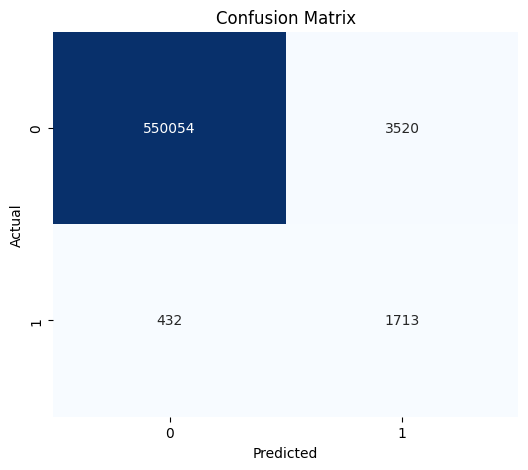

Total Missed Frauds: 432


In [ ]:
from sklearn.metrics import accuracy_score, recall_score

print("Running Batch Prediction on Test Data...")
results = predict_on_new_file('./../data/fraudTest.csv')

y_true = results['is_fraud']
y_pred = results['Predicted_Fraud']





print(classification_report(y_true, y_pred))



plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

missed = results[(y_true == 1) & (y_pred == 0)]
print(f"Total Missed Frauds: {len(missed)}")

In [ ]:
joblib.dump(voting_clf, 'model_fraude_v1.joblib')

['model_fraude_v1.joblib']